# 梯度下降相关实现

### 一.房价项目


=== 最终结果 ===

=== Final Results ===
Optimized θ₀ = 36308983011038112.0000
Optimized θ₁ = 471734594969116544.0000
Final Cost J(θ) = 10220520320057406476721998780757442560.000000
你的房子大概会花你：36831607390602129408.00 100 RMB
Total price: 3683160739060212826112.00 RMB


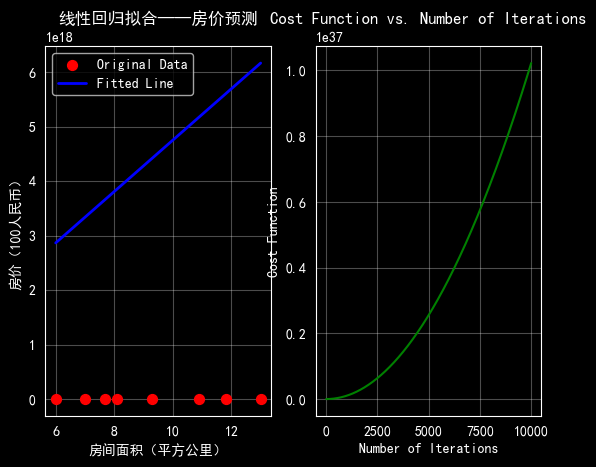

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号
x=np.array([6.0,7.0,7.7,8.1,9.3,10.9,11.8,13])
y=np.array([111,133,200,234,300,389,456,546])
m=len(x)
#初始化参数
theta0=np.random.uniform(-1,1)
theta1=np.random.uniform(-1,1)
alpha=0.01
iterations=10000
#定义代价函数J
def compute_cost(theta0,theta1,x,y,m):
    total_cost=0.001
    for i in range(m):
        h=theta0+theta1*x[i]
        total_cost+=(h-y[i])**2
    return total_cost/(2*m)
#梯度下降实现
#保存每次迭代的代价，用于绘图
cost_history=[]
for i in range(iterations):
    d_theta0=0
    d_theta1=0
    for j in range(m):
        h=d_theta0+d_theta1*x[j]
        #写公式
        d_theta0+=(h-y[j])
        d_theta1+=(h-y[j])*x[j]
    #更新theta
    theta0=theta0-alpha*(d_theta0/m)
    theta1=theta1-alpha*(d_theta1/m)
    #记录每次迭代的代价
    cost=compute_cost(theta0,theta1,x,y,m)
    cost_history.append(cost)  # 补充：把代价存入列表
#输出结果
print("\n=== 最终结果 ===")
print("\n=== Final Results ===")
print("Optimized θ₀ = {:.4f}".format(theta0))
print("Optimized θ₁ = {:.4f}".format(theta1))
print("Final Cost J(θ) = {:.6f}".format(compute_cost(theta0, theta1, x, y, m)))
#可视化结果
#子图1：原始数据+拟合曲线
plt.subplot(1,2,1)
plt.scatter(x, y, color="red", label="Original Data", s=50, zorder=3)
#生成lot(拟合直线的范围
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = theta0 + theta1 * x_fit
plt.plot(x_fit,y_fit,color="blue",label="Fitted Line",linewidth=2, zorder=2)
plt.xlabel("房间面积（平方公里）")
plt.ylabel("房价（100人民币）")
plt.title("线性回归拟合——房价预测")
plt.legend()
plt.grid(alpha=0.3, zorder=1)  # 增加网格，更易读
#子图2：代价函数随迭代次数的变化（验证收敛）
plt.subplot(1,2,2)
plt.plot(range(iterations),cost_history,color='green')
plt.xlabel('Number of Iterations')
plt.ylabel("Cost Function")
plt.title("Cost Function vs. Number of Iterations")
plt.grid(alpha=0.3)

#预测
input_area=input("你想买的房子预期面积为(单位：平方公里):")
x_test=float(input_area)
y_pred=theta0+theta1*x_test
print("你的房子大概会花你：{:.2f} 100 RMB".format(y_pred))
print("Total price: {:.2f} RMB".format(y_pred * 100))